In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
import random
import os
import tensorflow as tf

# Set random seeds for reproducibility
SEED = 120
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Configure TensorFlow deterministic operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Times New Roman']
plt.rcParams['axes.unicode_minus'] = True

print("✓ All libraries imported successfully")
print(f"✓ Random seed set to: {SEED}")

✓ All libraries imported successfully
✓ Random seed set to: 120


## Step 1: Data Loading and Timestamp Parsing

In [2]:
# Load data
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ Data loaded successfully, shape: {df.shape}")
except Exception as e:
    raise RuntimeError(f"Read failed: {e}")

# Display first few rows
print(f"\nFirst 5 rows of the dataset:")
print(df.head())

# Define key columns
time_col = df.columns[0]  # The first column is timestamp
target_col = df.columns[-1]  # The last column is the target (CO2 capacity)

print(f"\nColumn roles:")
print(f"  • Time column: {time_col}")
print(f"  • Target column: {target_col}")
print(f"  • Sampling frequency: 1 minute")
print(f"  • Total records: {len(df)}")

✓ Data loaded successfully, shape: (7200, 59)

First 5 rows of the dataset:
                 Date      PI-2       TI-2         FI-2      PI-3       TI-3  \
0 2020-01-20 00:00:00 -0.053126  34.736652  1543.938721  0.052434  45.023132   
1 2020-01-20 00:01:00 -0.053289  34.732132  1541.767578  0.052564  45.045799   
2 2020-01-20 00:02:00 -0.053386  34.761639  1545.614746  0.052390  45.088932   
3 2020-01-20 00:03:00 -0.053370  34.731682  1544.225952  0.052236  45.071358   
4 2020-01-20 00:04:00 -0.053144  34.718353  1540.848267  0.052370  45.036755   

       O2-3      TI-32      TI-33      TI-34  ...        FI-16      TI-16  \
0  5.170577  37.777477  50.215652  61.217957  ...  9634.049805  34.619560   
1  5.139907  37.836792  50.203251  61.241829  ...  9661.376953  34.598999   
2  5.078373  37.840168  50.180534  61.217957  ...  9662.280273  34.551292   
3  4.915955  37.849812  50.215652  61.322845  ...  9656.855469  34.583843   
4  5.042109  37.914433  50.229359  61.233147  ...  9641.30

## Step 2: Feature Selection and Chronological Split

In [3]:
# Selected 11 features (from correlation analysis)
selected_features = ['TI-34', 'TI-33', 'FI-30', 'FI-38', 'TI-4', 'TI-19', 'TI-12', 'TI-22', 'TI-24', 'TI-28','Level Reboiler']

# Check whether all selected features exist
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f"⚠ Warning: The following features are missing: {missing_features}")
    print(f"Actual columns: {list(df.columns)}")
    selected_features = [f for f in selected_features if f in df.columns]
    print(f"Using available features only: {selected_features}")

print(f"\nFeatures in use (total {len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# Extract features and target
X = df[selected_features].copy()
y = df[target_col].copy()

# Save timeline information for visualization
time_series = pd.to_datetime(df[time_col])

# Handle missing values (fill with median)
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

print(f"\nTarget variable statistics:")
print(f"  • Min: {y.min():.6f}")
print(f"  • Max: {y.max():.6f}")
print(f"  • Mean: {y.mean():.6f}")
print(f"  • Std: {y.std():.6f}")

# Chronological split: first 80% for training, last 20% for testing
split_idx = int(len(df) * 0.8)

X_train_raw = X.iloc[:split_idx].reset_index(drop=True)
X_test_raw = X.iloc[split_idx:].reset_index(drop=True)
y_train_raw = y.iloc[:split_idx].reset_index(drop=True)
y_test_raw = y.iloc[split_idx:].reset_index(drop=True)
time_train = time_series.iloc[:split_idx].reset_index(drop=True)
time_test = time_series.iloc[split_idx:].reset_index(drop=True)

print(f"\nChronological split results:")
print(f"  • Training data: {len(X_train_raw)} rows (first 80%)")
print(f"  • Test data: {len(X_test_raw)} rows (last 20%)")
print(f"  • Training time range: {time_train.min()} to {time_train.max()}")
print(f"  • Test time range: {time_test.min()} to {time_test.max()}")


Features in use (total 11):
  1. TI-34
  2. TI-33
  3. FI-30
  4. FI-38
  5. TI-4
  6. TI-19
  7. TI-12
  8. TI-22
  9. TI-24
  10. TI-28
  11. Level Reboiler

Target variable statistics:
  • Min: 0.582062
  • Max: 0.948009
  • Mean: 0.864631
  • Std: 0.045872

Chronological split results:
  • Training data: 5760 rows (first 80%)
  • Test data: 1440 rows (last 20%)
  • Training time range: 2020-01-20 00:00:00 to 2020-01-23 23:59:00
  • Test time range: 2020-01-24 00:00:00 to 2020-01-24 23:59:00


## Step 3: Feature Standardization (Using Training-Set Statistics)

In [4]:
# Compute mean and std on the training set
scaler = StandardScaler()
scaler.fit(X_train_raw)  # Fit only on training set

# Standardize training and test sets using training statistics
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Convert to DataFrame and keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=selected_features)

print("✓ Feature standardization completed")
print(f"\nTraining feature statistics (standardized):")
print(f"  • Mean: {X_train_scaled.mean().values}")
print(f"  • Variance: {X_train_scaled.var().values}")
print(f"\nSome test samples may fall outside [-1, 1], which is normal")

✓ Feature standardization completed

Training feature statistics (standardized):
  • Mean: [ 3.55271368e-16 -1.97372982e-16  2.36847579e-16  9.86864911e-16
  7.89491929e-16  1.81583144e-15 -5.52644350e-16 -7.10542736e-16
  3.55271368e-15 -2.94085743e-15 -8.88178420e-15]
  • Variance: [1.00017364 1.00017364 1.00017364 1.00017364 1.00017364 1.00017364
 1.00017364 1.00017364 1.00017364 1.00017364 1.00017364]

Some test samples may fall outside [-1, 1], which is normal


## Step 4: Sliding Window Construction

**Rule:** Use feature values from the previous 10 time steps (10 minutes) as input to predict the target at the next time step (the 11th minute).

In [5]:
def create_sliding_windows(X, y, window_size=10):
    """
    Build sliding-window samples.
    
    Parameters:
      X: Feature data (n_samples, n_features)
      y: Target data (n_samples,)
      window_size: Window length (default: 10)
    
    Returns:
      X_windows: Windowed features (n_windows, window_size * n_features)
      y_windows: Windowed targets (n_windows,)
    """
    X_windows = []
    y_windows = []
    
    for i in range(len(X) - window_size):
        # Take features from i to i+window_size-1 and flatten into one row
        window = X.iloc[i:i+window_size].values.flatten()
        X_windows.append(window)
        
        # Target is the value at time step i+window_size
        y_windows.append(y.iloc[i+window_size])
    
    return np.array(X_windows), np.array(y_windows)

# Build training windows
X_train_windows, y_train_windows = create_sliding_windows(X_train_scaled, y_train_raw, window_size=10)

# Build test windows
X_test_windows, y_test_windows = create_sliding_windows(X_test_scaled, y_test_raw, window_size=10)

print(f"✓ Sliding-window construction completed")
print(f"\nTraining data:")
print(f"  • Number of samples: {X_train_windows.shape[0]}")
print(f"  • Feature dimension: {X_train_windows.shape[1]} (10 minutes × {len(selected_features)} features)")
print(f"\nTest data:")
print(f"  • Number of samples: {X_test_windows.shape[0]}")
print(f"  • Feature dimension: {X_test_windows.shape[1]}")

print(f"\nSample example (first sample in training set):")
print(f"  Input shape: {X_train_windows[0].shape}")
print(f"  Input (first 20 values): {X_train_windows[0][:20]}")
print(f"  Target value: {y_train_windows[0]}")

✓ Sliding-window construction completed

Training data:
  • Number of samples: 5750
  • Feature dimension: 110 (10 minutes × 11 features)

Test data:
  • Number of samples: 1430
  • Feature dimension: 110

Sample example (first sample in training set):
  Input shape: (110,)
  Input (first 20 values): [-0.76269694 -0.77526843 -0.01724584 -0.18599427 -0.47915401 -0.50228309
 -0.52739672 -0.50061837 -0.84930908 -0.04796601  0.84070529 -0.75259289
 -0.78193782 -0.18912994 -0.1312676  -0.48068931 -0.52414832 -0.52561594
 -0.5051719  -0.84003087]
  Target value: 0.846168723536747


## Step 5: Reshape Data for LSTM

In [6]:
# Reshape flattened windows to (samples, time_steps, features)
X_train_lstm = X_train_windows.reshape((X_train_windows.shape[0], 10,11))
X_test_lstm = X_test_windows.reshape((X_test_windows.shape[0], 10, 11))

print(f"✓ Data reshaping completed")
print(f"\nReshaped data dimensions:")
print(f"  • Training data: {X_train_lstm.shape} (samples, time steps, features)")
print(f"  • Test data: {X_test_lstm.shape} (samples, time steps, features)")
print(f"  • Target variable: {y_train_windows.shape}")

## Step 6: LSTM Model Construction and Training

print("\nBuilding LSTM model...")
model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(10, 11)),
    Dropout(0.3),
    LSTM(64, activation='relu'),
    Dropout(0.3),
    Dense(1)  # Output layer: predict a single value
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print(f"✓ Model construction completed")
print(f"\nModel architecture:")
model.summary()

print(f"\nModel configuration:")
print(f"  • Model type: LSTM neural network")
print(f"  • Hidden layer 1: LSTM 64 units + Dropout(0.4)")
print(f"  • Hidden layer 2: LSTM 64 units + Dropout(0.4)")
print(f"  • Output layer: Dense 1 unit")
print(f"  • Optimizer: Adam(learning_rate=0.001)")
print(f"  • Loss function: MSE (Mean Squared Error)")

# Define early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

print(f"\nTraining model...")
print(f"  • Batch size: 32")
print(f"  • Number of epochs: 150 (with Early Stopping)")
print(f"  • Validation split: 20%")

# Train model
history = model.fit(
    X_train_lstm, y_train_windows,
    batch_size=32,
    epochs=150,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\n✓ Model training completed")
print(f"  • Actual training epochs: {len(history.history['loss'])}")
print(f"  • Final training loss: {history.history['loss'][-1]:.6f}")
print(f"  • Final validation loss: {history.history['val_loss'][-1]:.6f}")

# Training-set performance
print(f"\nComputing training-set performance...")
y_train_pred = model.predict(X_train_lstm, verbose=0)
y_train_pred = y_train_pred.flatten()

train_r2 = r2_score(y_train_windows, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_windows, y_train_pred))
train_mae = mean_absolute_error(y_train_windows, y_train_pred)

print(f"\nTraining-set performance:")
print(f"  • R²: {train_r2:.4f}")
print(f"  • RMSE: {train_rmse:.6f}")
print(f"  • MAE: {train_mae:.6f}")

✓ Data reshaping completed

Reshaped data dimensions:
  • Training data: (5750, 10, 11) (samples, time steps, features)
  • Test data: (1430, 10, 11) (samples, time steps, features)
  • Target variable: (5750,)

Building LSTM model...
✓ Model construction completed

Model architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 64)            19456     
                                                                 
 dropout (Dropout)           (None, 10, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (Non

## Step 7: Model Performance Evaluation (Test Set)

In [7]:
# Predict on the test set
y_test_pred = model.predict(X_test_lstm, verbose=0)
y_test_pred = y_test_pred.flatten()

# Compute performance metrics
test_r2 = r2_score(y_test_windows, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_windows, y_test_pred))
test_mae = mean_absolute_error(y_test_windows, y_test_pred)

# Compute residuals
residuals = y_test_windows - y_test_pred
residuals_std = np.std(residuals)
residuals_mean = np.mean(residuals)

# Compute MAPE (Mean Absolute Percentage Error)
test_mape = np.mean(np.abs((y_test_windows - y_test_pred) / y_test_windows)) * 100

# Compute WQL (Weighted Quantile Loss)
def weighted_quantile_loss(y_true, y_pred, quantiles=[0.1, 0.5, 0.9]):
    """
    Compute Weighted Quantile Loss (WQL).
    Evaluates predictive uncertainty and performance at multiple quantiles.
    """
    losses = []
    for q in quantiles:
        errors = y_true - y_pred
        loss = np.maximum(q * errors, (q - 1) * errors)
        losses.append(np.mean(loss))
    return np.mean(losses)

test_wql = weighted_quantile_loss(y_test_windows, y_test_pred)

print("="*80)
print("Test Set Performance Evaluation")
print("="*80)

print(f"\n[Prediction Accuracy Metrics]")
print(f"  • R² score: {test_r2:.4f}")
print(f"    └─ Interpretation: the model explains {test_r2*100:.2f}% of target variance")
print(f"  • RMSE (Root Mean Squared Error): {test_rmse:.6f}")
print(f"    └─ Interpretation: average prediction deviation")
print(f"  • MAE (Mean Absolute Error): {test_mae:.6f}")
print(f"    └─ Interpretation: average absolute deviation")
print(f"  • MAPE (Mean Absolute Percentage Error): {test_mape:.2f}%")
print(f"    └─ Interpretation: percentage representation of prediction error")
print(f"  • WQL (Weighted Quantile Loss): {test_wql:.6f}")
print(f"    └─ Interpretation: average loss across quantiles (0.1, 0.5, 0.9)")

print(f"\n[Actual vs Predicted Statistics]")
print(f"  Actual values:")
print(f"    • Min: {y_test_windows.min():.6f}, Max: {y_test_windows.max():.6f}")
print(f"    • Mean: {y_test_windows.mean():.6f}, Std: {y_test_windows.std():.6f}")
print(f"  Predicted values:")
print(f"    • Min: {y_test_pred.min():.6f}, Max: {y_test_pred.max():.6f}")
print(f"    • Mean: {y_test_pred.mean():.6f}, Std: {y_test_pred.std():.6f}")

print(f"\n[Residual Analysis]")
print(f"  • Residual mean: {residuals_mean:.6f} (closer to 0 is better)")
print(f"  • Residual std: {residuals_std:.6f}")
print(f"  • Residual min: {residuals.min():.6f}")
print(f"  • Residual max: {residuals.max():.6f}")

Test Set Performance Evaluation

[Prediction Accuracy Metrics]
  • R² score: 0.9251
    └─ Interpretation: the model explains 92.51% of target variance
  • RMSE (Root Mean Squared Error): 0.011381
    └─ Interpretation: average prediction deviation
  • MAE (Mean Absolute Error): 0.008266
    └─ Interpretation: average absolute deviation
  • MAPE (Mean Absolute Percentage Error): 0.99%
    └─ Interpretation: percentage representation of prediction error
  • WQL (Weighted Quantile Loss): 0.004133
    └─ Interpretation: average loss across quantiles (0.1, 0.5, 0.9)

[Actual vs Predicted Statistics]
  Actual values:
    • Min: 0.735384, Max: 0.914714
    • Mean: 0.852431, Std: 0.041595
  Predicted values:
    • Min: 0.750841, Max: 0.894184
    • Mean: 0.856837, Std: 0.036589

[Residual Analysis]
  • Residual mean: -0.004406 (closer to 0 is better)
  • Residual std: 0.010493
  • Residual min: -0.083140
  • Residual max: 0.046386


## Step 8: Result Visualization

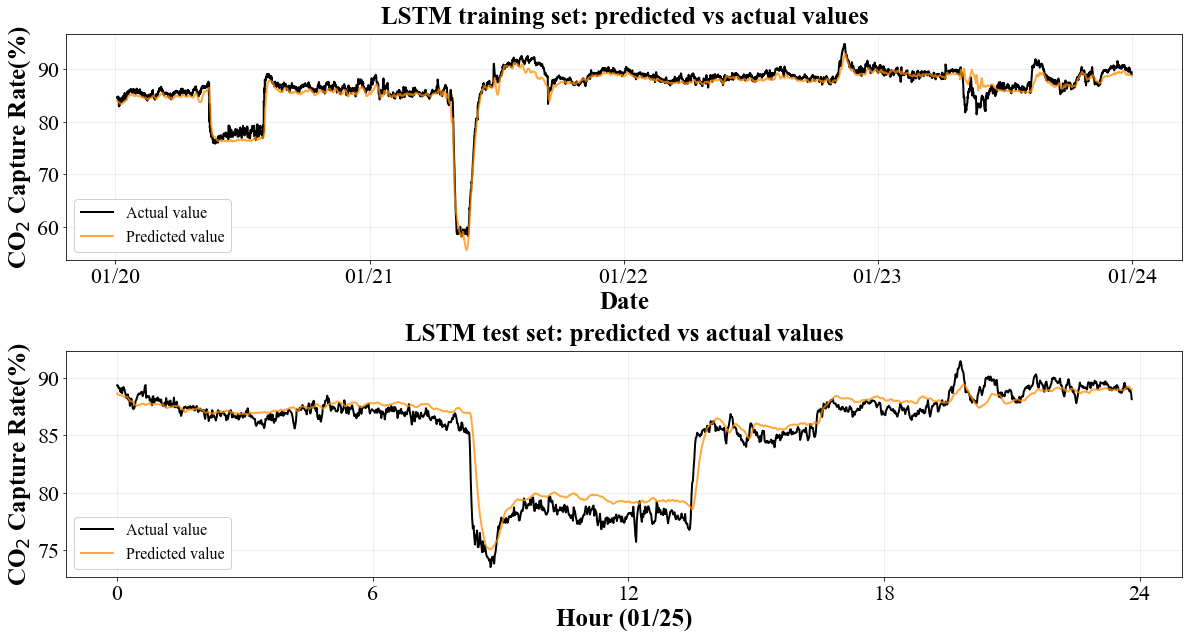

✓ Visualization figure saved as 'time_series_prediction_results.png'
  • Training date range: 01/20 to 01/24 (5750 points)
  • Test time range: 01/25 (23.82 hours)


In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# Ensure the 1st figure always displays inline
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

# Close any previously-open figures
plt.close('all')

# Convert capture-rate values to 0–100 scale (ticks show numbers without %)
_capture_candidates = [y_train_windows, y_train_pred, y_test_windows, y_test_pred]
_capture_max = np.nanmax([np.nanmax(np.asarray(v)) for v in _capture_candidates])
_need_times_100 = _capture_max <= 1.5

def _to_pct_values(arr):
    arr = np.asarray(arr)
    return arr * 100.0 if _need_times_100 else arr

y_train_windows_pct = _to_pct_values(y_train_windows)
y_train_pred_pct = _to_pct_values(y_train_pred)
y_test_windows_pct = _to_pct_values(y_test_windows)
y_test_pred_pct = _to_pct_values(y_test_pred)

# Get aligned timeline for training data
train_dates_original = time_train.iloc[10:10+len(y_train_windows)]

# Use Times New Roman + size 12 for the whole figure
with plt.rc_context({'font.family': 'Times New Roman', 'font.size': 12}):
    # Keep only two plots: full training sequence comparison + full test sequence comparison
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 1, hspace=0.40)

    # Test set: create hour sequence (0-24 hours)
    test_hours = np.arange(len(y_test_windows)) / 60  # Convert to hours (one point per minute)

    # Plot 1: training set prediction comparison (full sequence)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(train_dates_original, y_train_windows_pct, '-', label='Actual value', linewidth=2, color='black')
    ax1.plot(train_dates_original, y_train_pred_pct, '-', label='Predicted value', linewidth=2, alpha=0.75, color='darkorange')
    ax1.set_xlabel('Date', fontsize=25, fontweight='bold')
    ax1.set_ylabel('CO$_2$ Capture Rate(%)', fontsize=25, fontweight='bold')
    ax1.set_title('LSTM training set: predicted vs actual values', fontweight='bold', fontsize=25, pad=10)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax1.xaxis.set_major_locator(mdates.DayLocator())
    ax1.tick_params(axis='both', labelsize=22)
    ax1.legend(loc='best', fontsize=16, framealpha=0.9)
    ax1.grid(True, alpha=0.25, linewidth=0.8)

    # Plot 2: test set prediction comparison (full sequence)
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(test_hours, y_test_windows_pct, '-', label='Actual value', linewidth=2, color='black')
    ax2.plot(test_hours, y_test_pred_pct, '-', label='Predicted value', linewidth=2, alpha=0.75, color='darkorange')
    ax2.set_xlabel('Hour (01/25)', fontsize=25, fontweight='bold')
    ax2.set_ylabel('CO$_2$ Capture Rate(%)', fontsize=25, fontweight='bold')
    ax2.set_title('LSTM test set: predicted vs actual values', fontweight='bold', fontsize=25, pad=10)
    # Set x-axis ticks at 6-hour intervals
    ax2.set_xticks(np.arange(0, max(test_hours) + 1, 6))
    ax2.tick_params(axis='both', labelsize=22)
    ax2.legend(loc='best', fontsize=16, framealpha=0.9)
    ax2.grid(True, alpha=0.25, linewidth=0.8)

    plt.savefig('time_series_prediction_results.png', dpi=300, bbox_inches='tight')
    plt.show()

print("✓ Visualization figure saved as 'time_series_prediction_results.png'")
print(f"  • Training date range: 01/20 to 01/24 ({len(y_train_windows)} points)")
print(f"  • Test time range: 01/25 ({test_hours.max():.2f} hours)")

## Step 9: Training Process Visualization

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

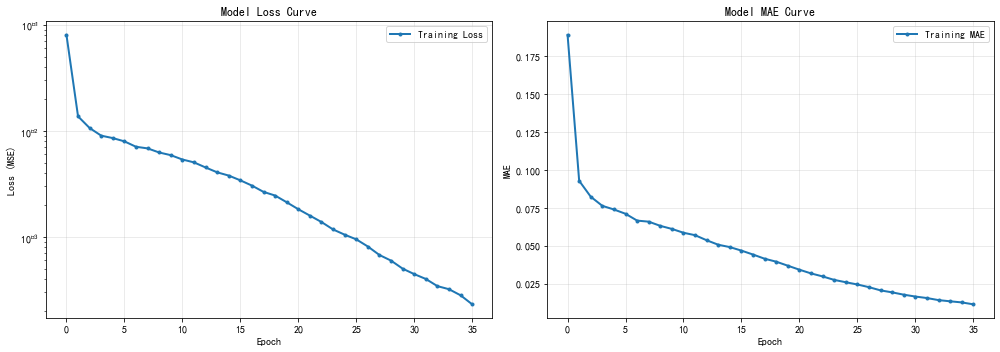

✓ Training curves saved as 'training_history.png'

[Training Summary]
  • Total epochs: 36
  • Initial training loss: 0.080377
  • Final training loss: 0.000232
  • Loss reduction ratio: 99.71%


In [9]:
# Visualize training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: loss function curve
ax1 = axes[0]
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2, marker='o', markersize=3)
ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Loss (MSE)', fontweight='bold')
ax1.set_title('Model Loss Curve', fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: MAE curve
ax2 = axes[1]
ax2.plot(history.history['mae'], label='Training MAE', linewidth=2, marker='o', markersize=3)
ax2.set_xlabel('Epoch', fontweight='bold')
ax2.set_ylabel('MAE', fontweight='bold')
ax2.set_title('Model MAE Curve', fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved as 'training_history.png'")

# Training summary
print("\n[Training Summary]")
print(f"  • Total epochs: {len(history.history['loss'])}")
print(f"  • Initial training loss: {history.history['loss'][0]:.6f}")
print(f"  • Final training loss: {history.history['loss'][-1]:.6f}")
print(f"  • Loss reduction ratio: {(1 - history.history['loss'][-1] / history.history['loss'][0]) * 100:.2f}%")

## Step 10: Summary and File Export

In [10]:
# Create summary report
summary_report = f"""
{'='*80}
Time Series Prediction Performance Summary (LSTM Neural Network)
{'='*80}

[Data Configuration]
  • Number of original data points: {len(df)}
  • Sampling frequency: 1 minute per record
  • Time span: approximately {len(df)} minutes
  • Number of selected features: {len(selected_features)}

[Data Split]
  • Training set: {len(X_train_raw)} rows (first 80%)
  • Test set: {len(X_test_raw)} rows (last 20%)
  • Training windows: {len(X_train_windows)} (10 minutes per window)
  • Test windows: {len(X_test_windows)} (10 minutes per window)

[Model Configuration]
  • Model type: LSTM neural network
  • Input shape: (samples, 10 time steps, 10 features)
  • Hidden layer 1: LSTM 64 units + Dropout(0.4) + return_sequences=True
  • Hidden layer 2: LSTM 64 units + Dropout(0.4)
  • Output layer: Dense 1 unit
  • Optimizer: Adam(learning_rate=0.001)
  • Loss function: MSE (Mean Squared Error)
  • Forecast task: previous 10 minutes -> next 1 minute

[Training Configuration]
  • Batch size: 32
  • Number of epochs: 150 (with Early Stopping)
  • Actual training epochs: {len(history.history['loss'])}
  • Early Stopping: monitor training loss, patience=20
  • Shuffle data: No (preserve temporal order)

[Performance Metrics]

  Training set:
    • R²: {train_r2:.4f}
    • RMSE: {train_rmse:.6f}
    • MAE: {train_mae:.6f}

  Test set:
    • R²: {test_r2:.4f}
    • RMSE: {test_rmse:.6f}
    • MAE: {test_mae:.6f}
    • MAPE: {test_mape:.2f}%
    • WQL: {test_wql:.6f}

[Prediction Accuracy Interpretation]
  • R² = {test_r2:.4f}: the model explains {test_r2*100:.2f}% of target variance on the test set
  • RMSE = {test_rmse:.6f}: average prediction error (on original data scale)
  • MAE = {test_mae:.6f}: average absolute deviation
  • MAPE = {test_mape:.2f}%: mean absolute percentage error
  • WQL = {test_wql:.6f}: weighted quantile loss (performance across different quantiles)

[Residual Analysis]
  • Residual mean: {residuals_mean:.6f} (close to 0 indicates unbiased prediction)
  • Residual standard deviation: {residuals_std:.6f}
  • Residual range: [{residuals.min():.6f}, {residuals.max():.6f}]

[Training Process]
  • Initial training loss: {history.history['loss'][0]:.6f}
  • Final training loss: {history.history['loss'][-1]:.6f}
  • Loss reduction ratio: {(1 - history.history['loss'][-1] / history.history['loss'][0]) * 100:.2f}%

{'='*80}
"""

print(summary_report)

# Save report
with open('time_series_prediction_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)
print("✓ Report saved as 'time_series_prediction_report.txt'")


Time Series Prediction Performance Summary (LSTM Neural Network)

[Data Configuration]
  • Number of original data points: 7200
  • Sampling frequency: 1 minute per record
  • Time span: approximately 7200 minutes
  • Number of selected features: 11

[Data Split]
  • Training set: 5760 rows (first 80%)
  • Test set: 1440 rows (last 20%)
  • Training windows: 5750 (10 minutes per window)
  • Test windows: 1430 (10 minutes per window)

[Model Configuration]
  • Model type: LSTM neural network
  • Input shape: (samples, 10 time steps, 10 features)
  • Hidden layer 1: LSTM 64 units + Dropout(0.4) + return_sequences=True
  • Hidden layer 2: LSTM 64 units + Dropout(0.4)
  • Output layer: Dense 1 unit
  • Optimizer: Adam(learning_rate=0.001)
  • Loss function: MSE (Mean Squared Error)
  • Forecast task: previous 10 minutes -> next 1 minute

[Training Configuration]
  • Batch size: 32
  • Number of epochs: 150 (with Early Stopping)
  • Actual training epochs: 36
  • Early Stopping: monitor tr

In [11]:
# Save predictions to CSV
results_df = pd.DataFrame({
    'Time Step': np.arange(len(y_test_windows)),
    'Actual Value': y_test_windows,
    'Predicted Value': y_test_pred,
    'Residual': residuals,
    'Absolute Error': np.abs(residuals),
    'Relative Error (%)': np.abs(residuals) / np.abs(y_test_windows) * 100
})

results_df.to_csv('time_series_predictions.csv', index=False, encoding='utf-8-sig')
print("✓ Prediction results saved as 'time_series_predictions.csv'")

# Save test-set predictions to Excel (Time + Predicted Value only)
test_time_aligned = time_test.iloc[10:10 + len(y_test_pred)].reset_index(drop=True)
test_pred_excel_df = pd.DataFrame({
    'Time': test_time_aligned,
    'Predicted Value': y_test_pred
})
test_pred_excel_df.to_excel('test_predictions.xlsx', index=False)
print("✓ Test predictions Excel saved as 'test_predictions.xlsx'")

# Save performance metrics summary
metrics_summary = pd.DataFrame({
    'Metric': ['R²', 'RMSE', 'MAE', 'MAPE(%)', 'WQL', 'Residual Mean', 'Residual Std'],
    'Training Set': [train_r2, train_rmse, train_mae, np.nan, np.nan, np.nan, np.nan],
    'Test Set': [test_r2, test_rmse, test_mae, test_mape, test_wql, residuals_mean, residuals_std]
})

metrics_summary.to_csv('performance_metrics.csv', index=False, encoding='utf-8-sig')
print("✓ Performance metrics saved as 'performance_metrics.csv'")

# Save model
model.save('lstm_model.h5')
print("✓ LSTM model saved as 'lstm_model.h5'")

print("\n" + "="*80)
print("✅ All files have been generated successfully!")
print("="*80)
print("\nGenerated files:")
print("  1. time_series_prediction_results.png - Prediction visualization")
print("  2. training_history.png - Training-process visualization (loss and MAE curves)")
print("  3. time_series_prediction_report.txt - Performance summary report")
print("  4. time_series_predictions.csv - Detailed prediction results")
print("  5. test_predictions.xlsx - Test set predicted values (Time + Predicted Value)")
print("  6. performance_metrics.csv - Performance metrics summary")
print("  7. lstm_model.h5 - Trained LSTM model")

✓ Prediction results saved as 'time_series_predictions.csv'
✓ Test predictions Excel saved as 'test_predictions.xlsx'
✓ Performance metrics saved as 'performance_metrics.csv'
✓ LSTM model saved as 'lstm_model.h5'

✅ All files have been generated successfully!

Generated files:
  1. time_series_prediction_results.png - Prediction visualization
  2. training_history.png - Training-process visualization (loss and MAE curves)
  3. time_series_prediction_report.txt - Performance summary report
  4. time_series_predictions.csv - Detailed prediction results
  5. test_predictions.xlsx - Test set predicted values (Time + Predicted Value)
  6. performance_metrics.csv - Performance metrics summary
  7. lstm_model.h5 - Trained LSTM model
